## YZTA 2026 Datathon: Cognitive Performance Score Prediction

### Data Cleaning

This notebook was created to analyze a dataset containing individuals' sleep patterns, lifestyle habits, and daily situations, and to prepare it for machine learning models.

The goal is to clean the data in a way that minimizes the RMSE score, strategically fill in missing values, and derive new features that will improve the model's success.

#### 1. Setup

In [3]:
#Import necessary libraries.
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


#### 2. Load Data

In [4]:
df = pd.read_csv("../data/raw/train.csv")

#### 3. Discover and Clean The Data

##### 📊 Data Dictionary

This project utilizes a dataset containing sleep patterns, lifestyle habits, and daily metrics to predict cognitive performance scores. Below is the mapping of original Turkish column names to their English counterparts used in this analysis:

| Original Column Name | English Translation | Description |
| :--- | :--- | :--- |
| `id` | `id` | Unique identifier for each participant |
| `yas` | `age` | Participant's age |
| `cinsiyet` | `gender` | Gender (Male/Female) |
| `meslek` | `occupation` | Professional category |
| `vucut_kitle_indeksi` | `bmi` | Body Mass Index |
| `ulke` | `country` | Country of residence |
| `rem_yuzdesi` | `rem_percentage` | Percentage of REM sleep in total sleep |
| `derin_uyku_yuzdesi` | `deep_sleep_percentage` | Percentage of deep sleep in total sleep |
| `uykuya_dalma_suresi_dk` | `sleep_latency_min` | Time taken to fall asleep (minutes) |
| `gecelik_uyanma_sayisi` | `nightly_awakenings` | Number of times woken up during the night |
| `uyku_oncesi_kafein_mg` | `pre_sleep_caffeine_mg` | Caffeine intake before bed (milligrams) |
| `uyku_oncesi_ekran_suresi_dk` | `pre_sleep_screen_time` | Screen time exposure before bed (minutes) |
| `gunluk_adim_sayisi` | `daily_steps` | Total step count for the day |
| `sekerleme_suresi_dk` | `nap_duration_min` | Duration of daytime naps (minutes) |
| `stres_skoru` | `stress_score` | Numerical value representing stress level |
| `gunluk_calisma_saati` | `daily_work_hours` | Total working hours for the day |
| `kronotip` | `chronotype` | Individual's biological rhythm/sleep tendency |
| `ruh_sagligi_durumu` | `mental_health_status` | Categorical status of mental well-being |
| `dinlenik_nabiz_bpm` | `resting_heart_rate` | Heart rate at rest (beats per minute) |
| `oda_sicakligi_celsius` | `room_temp_celsius` | Temperature of the sleeping environment |
| `hafta_sonu_uyku_farki_saat`| `weekend_sleep_diff` | Difference in sleep duration on weekends (hours) |
| `mevsim` | `season` | The season when the observation was recorded |
| `gun_tipi` | `day_type` | Weekday or Weekend indicator |
| **`bilissel_performans_skoru`** | **`cognitive_score`** | **Target Variable: Cognitive performance level** |

---

> **Note:** For the sake of consistency with the Kaggle competition requirements, original column names are maintained in the source code, while the analysis and documentation are provided in English.

##### 3.1 Get Information

In [5]:
#Check the first few rows of the dataframe to understand its structure and contents.
df.head()

,id,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,1,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,2,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,3,39,Erkek,Ev Hanimi,21.533898,Spain,18.178857,25.530104,33,7,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,4,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,5,36,Kadin,NaN,NaN,Portekiz,25.468018,16.356738,21,8,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


In [6]:
#Column of the dataset
df.columns

Index(['id', 'yas', 'cinsiyet', 'meslek', 'vucut_kitle_indeksi', 'ulke',
       'rem_yuzdesi', 'derin_uyku_yuzdesi', 'uykuya_dalma_suresi_dk',
       'gecelik_uyanma_sayisi', 'uyku_oncesi_kafein_mg',
       'uyku_oncesi_ekran_suresi_dk', 'gunluk_adim_sayisi',
       'sekerleme_suresi_dk', 'stres_skoru', 'gunluk_calisma_saati',
       'kronotip', 'ruh_sagligi_durumu', 'dinlenik_nabiz_bpm',
       'oda_sicakligi_celsius', 'hafta_sonu_uyku_farki_saat', 'mevsim',
       'gun_tipi', 'bilissel_performans_skoru'],
      dtype='object')

In [7]:
#Check the shape of the dataframe to understand the number of rows and columns.
df.shape

(56000, 24)

In [8]:
#Get a summary of the dataframe to understand the distribution of values in each column and identify any potential issues with the data.
df.describe()

,id,yas,vucut_kitle_indeksi,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,uyku_oncesi_ekran_suresi_dk,gunluk_adim_sayisi,sekerleme_suresi_dk,stres_skoru,gunluk_calisma_saati,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,bilissel_performans_skoru
count,56000.000000,56000.000000,54248.000000,56000.000000,56000.000000,56000.000000,56000.000000,54537.000000,56000.000000,56000.000000,56000.000000,54285.000000,56000.000000,56000.000000,56000.000000,56000.000000,56000.000000
mean,28000.500000,34.714446,26.273651,20.233500,20.246063,20.107536,3.344929,42.110952,63.511446,7493.197554,15.432875,5.741407,7.156456,66.603214,20.531263,1.199050,5.913096
std,16165.951874,11.052508,4.495138,3.442993,4.300421,8.063278,2.034618,72.154159,44.590737,3462.699361,21.104672,1.624985,3.469731,7.353174,2.903317,0.790899,2.231759
min,1.000000,18.000000,16.000000,10.000000,5.000000,1.000000,0.000000,0.000000,2.000000,500.000000,0.000000,1.000000,0.000000,45.000000,15.000000,-1.000000,0.000000
25%,14000.750000,26.000000,23.175279,17.951724,17.337866,14.000000,2.000000,0.000000,30.000000,5042.000000,0.000000,4.761271,4.765942,62.000000,18.457240,0.660030,4.397431
50%,28000.500000,33.000000,26.225806,20.302218,20.292151,20.000000,3.000000,3.000000,51.000000,7426.000000,2.000000,5.824014,7.360860,67.000000,20.487456,1.202921,6.032249
75%,42000.250000,42.000000,29.321503,22.598180,23.227117,25.000000,5.000000,77.000000,84.000000,9876.000000,30.000000,6.837436,9.684531,72.000000,22.522152,1.743940,7.574980
max,56000.000000,69.000000,45.000000,30.000000,30.000000,58.000000,8.000000,400.000000,180.000000,20000.000000,115.000000,10.000000,18.000000,97.000000,28.000000,3.000000,10.000000


##### 3.2 Missing Value and Data Type Check

In [9]:
#Get information about the dataframe to understand the data types of each column.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           56000 non-null  int64  
 1   yas                          56000 non-null  int64  
 2   cinsiyet                     56000 non-null  object 
 3   meslek                       54622 non-null  object 
 4   vucut_kitle_indeksi          54248 non-null  float64
 5   ulke                         56000 non-null  object 
 6   rem_yuzdesi                  56000 non-null  float64
 7   derin_uyku_yuzdesi           56000 non-null  float64
 8   uykuya_dalma_suresi_dk       56000 non-null  int64  
 9   gecelik_uyanma_sayisi        56000 non-null  int64  
 10  uyku_oncesi_kafein_mg        54537 non-null  float64
 11  uyku_oncesi_ekran_suresi_dk  56000 non-null  int64  
 12  gunluk_adim_sayisi           56000 non-null  int64  
 13  sekerleme_suresi

* There are no errors in the data types, but some columns are missing data:
    1. meslek (occupation): 1378 
    2. vucut_kitle_indeksi (body_mass_index): 1752
    3. uyku_oncesi_kafein_mg (pre_sleep_caffeine): 1463
    4. stres_skoru (stress_score): 1715
    5. kronotip (chronotype): 1968
    6. ruh_sagligi_durumu (mental_health_status): 1096

 

Let's check for duplicate values ​​before dealing with missing values.

##### 3.3 Duplicate Check

In [10]:
#Check for duplicates in the dataset.
df.duplicated().sum()

np.int64(0)

##### 3.4 Misspelled Value Check

In [11]:
#Function to check misspelled values in categorical columns.
def check_unique_values(df, columns):
    for col in columns:
        unique_vals = df[col].unique()
        print(f"Column: {col}")
        print(f"Number of unique values: {len(unique_vals)}")
        print(f"Unique values: {unique_vals}\n")
        

In [12]:
#Identify categorical columns to a list.
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

#Check the result.
print(categorical_cols)

['cinsiyet', 'meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu', 'mevsim', 'gun_tipi']


In [13]:
#Check unique values in categorical columns.
check_unique_values(df, categorical_cols)

Column: cinsiyet
Number of unique values: 2
Unique values: ['Erkek' 'Kadin']

Column: meslek
Number of unique values: 12
Unique values: ['Saglik Personeli' 'Muhendis' 'Ev Hanimi' 'Egitimci' nan
 'Satis ve Pazarlama Calisani' 'Yonetici' 'Lawyer' 'Emekli' 'Ogrenci'
 'Lojistik Calisani' 'Serbest Calisan']

Column: ulke
Number of unique values: 15
Unique values: ['Cin' 'Amerika' 'Spain' 'Yeni Zelanda' 'Portekiz' 'South Korea' 'Fransa'
 'Ispanya' 'Ingiltere' 'Netherlands' 'Arjantin' 'Guney Kore' 'Isvec'
 'Sweden' 'Mexico']

Column: kronotip
Number of unique values: 4
Unique values: ['Sabah insani' 'Gece insani' 'Notr' nan]

Column: ruh_sagligi_durumu
Number of unique values: 5
Unique values: ['Anksiyete ve depresyon' 'Saglikli' 'Depresyon' 'Anksiyete' nan]

Column: mevsim
Number of unique values: 2
Unique values: ['Sonbahar-Kis' 'Ilkbahar-Yaz']

Column: gun_tipi
Number of unique values: 2
Unique values: ['Hafta ici' 'Hafta sonu']



> In the ulke(country) column, we see that some countries' names are listed in both English and Turkish. We need to correct this. For consistency, let's translate them to Turkish.
- Sweden --> Isvec
- South Korea --> Guney Kore
- Spain --> Ispanya

> For consistency,
- Lawyer --> Avukat
- Mexico --> Meksika
- Netherlands --> Hollanda

In [14]:
country_map = {
    'Spain': 'Ispanya',
    'South Korea': 'Guney Kore',
    'Sweden': 'Isvec',
    'Mexico': 'Meksika', 
    'Netherlands': 'Hollanda'
}

df['ulke'] = df['ulke'].replace(country_map)

In [15]:
df['ulke'].unique()

array(['Cin', 'Amerika', 'Ispanya', 'Yeni Zelanda', 'Portekiz',
       'Guney Kore', 'Fransa', 'Ingiltere', 'Hollanda', 'Arjantin',
       'Isvec', 'Meksika'], dtype=object)

##### 3.5 Handle Missing Values

In [16]:
# Clean the dataset by removing leading and trailing whitespace from string columns.
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# Convert nan-like values to actual NaN values for easier handling of missing data.
df = df.replace(['nan', 'NaN', '?', 'None', '', 'null', 'NULL'], np.nan)

# Check the result of cleaning.
print(df.isnull().sum())

id                                0
yas                               0
cinsiyet                          0
meslek                         1378
vucut_kitle_indeksi            1752
ulke                              0
rem_yuzdesi                       0
derin_uyku_yuzdesi                0
uykuya_dalma_suresi_dk            0
gecelik_uyanma_sayisi             0
uyku_oncesi_kafein_mg          1463
uyku_oncesi_ekran_suresi_dk       0
gunluk_adim_sayisi                0
sekerleme_suresi_dk               0
stres_skoru                    1715
gunluk_calisma_saati              0
kronotip                       1968
ruh_sagligi_durumu             1096
dinlenik_nabiz_bpm                0
oda_sicakligi_celsius             0
hafta_sonu_uyku_farki_saat        0
mevsim                            0
gun_tipi                          0
bilissel_performans_skoru         0
dtype: int64


* Meslek(Occupation) - 1378 missing:

> Strategy: Create a "Unknown" or "Other" category.

> Why? Individuals without occupation information may exhibit a common pattern in their cognitive performance or stress levels. Assigning them to the most frequently occurring occupation (mode) can pollute the data.

* Kronotip (Chronotype) - 1968 missing:

> Strategy: Fill with the most frequently occurring value (Mode).

> Why? Chronotype (morning person/night person) is a personal characteristic, and the majority of the population usually belongs to a particular group. Using a mode is safe because the number of missing entries is small.

* ruh_sagligi_durumu (Mental_health_status) - 1096 missing:

> Strategy: Create a "Not Specified" category.

> Why? The absence of this data does not mean the person's status is "Healthy." "Not Specified" allows the model to use this ambiguity as a signal. 

* vucut_kitle_indeksi (Body_Mass_Index) - 1752 missing:

> Strategy: Fill in with the Median.

> Why? BMI data may contain outliers (very high weights). The mean is affected by these extremes, but the median is more resilient.

* uyku_oncesi_kafein_mg (Before_sleep_caffeine_mg) - 1463 missing:

> Strategy: Fill in with "0" (Zero) or the Median.

> Why? In these types of surveys, people who don't consume caffeine tend to leave that space blank. If the data distribution is very close to 0, fill it with 0; otherwise, fill it with the median.

* stres_skoru (Stress_Score) - 1715 missing:

> Strategy: Group by Median.

> Why? The stress score is not a random number. For example, the stress score of someone with a "Mental Health Status" of Depression is different from that of someone who is Healthy.


In [17]:
#Handle missing values by filling them with appropriate values based on the context of each column.
df['meslek'] = df['meslek'].fillna('Bilinmiyor')

df['kronotip'] = df['kronotip'].fillna(df['kronotip'].mode()[0])

df['ruh_sagligi_durumu'] = df['ruh_sagligi_durumu'].fillna('Bilinmiyor')

df['vucut_kitle_indeksi'] = df['vucut_kitle_indeksi'].fillna(df['vucut_kitle_indeksi'].median())

df['uyku_oncesi_kafein_mg'] = df['uyku_oncesi_kafein_mg'].fillna(df['uyku_oncesi_kafein_mg'].median())

df['stres_skoru'] = df.groupby('ruh_sagligi_durumu')['stres_skoru'].transform(lambda x: x.fillna(x.median()))

In [18]:
df.isnull().sum()

id                             0
yas                            0
cinsiyet                       0
meslek                         0
vucut_kitle_indeksi            0
ulke                           0
rem_yuzdesi                    0
derin_uyku_yuzdesi             0
uykuya_dalma_suresi_dk         0
gecelik_uyanma_sayisi          0
uyku_oncesi_kafein_mg          0
uyku_oncesi_ekran_suresi_dk    0
gunluk_adim_sayisi             0
sekerleme_suresi_dk            0
stres_skoru                    0
gunluk_calisma_saati           0
kronotip                       0
ruh_sagligi_durumu             0
dinlenik_nabiz_bpm             0
oda_sicakligi_celsius          0
hafta_sonu_uyku_farki_saat     0
mevsim                         0
gun_tipi                       0
bilissel_performans_skoru      0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

##### 3.6 Drop Unnecessary Columns

In [20]:
#We don't need the id column for our analysis, so we can drop it.
df = df.drop(['id'], axis = 1)
df.head()

,yas,cinsiyet,meslek,vucut_kitle_indeksi,ulke,rem_yuzdesi,derin_uyku_yuzdesi,uykuya_dalma_suresi_dk,gecelik_uyanma_sayisi,uyku_oncesi_kafein_mg,...,stres_skoru,gunluk_calisma_saati,kronotip,ruh_sagligi_durumu,dinlenik_nabiz_bpm,oda_sicakligi_celsius,hafta_sonu_uyku_farki_saat,mevsim,gun_tipi,bilissel_performans_skoru
0,34,Erkek,Saglik Personeli,31.470103,Cin,14.431210,14.645436,27,7,0.0,...,9.922976,10.045274,Sabah insani,Anksiyete ve depresyon,78,18.962436,-0.074140,Sonbahar-Kis,Hafta ici,0.136441
1,32,Kadin,Muhendis,30.981394,Amerika,21.771870,27.220360,20,4,4.0,...,6.626400,6.319245,Gece insani,Saglikli,76,21.225666,0.942672,Sonbahar-Kis,Hafta ici,5.848312
2,39,Erkek,Ev Hanimi,21.533898,Ispanya,18.178857,25.530104,33,7,148.0,...,6.093566,3.824463,Notr,Depresyon,66,18.482409,1.239886,Ilkbahar-Yaz,Hafta sonu,6.828276
3,40,Kadin,Egitimci,23.310749,Yeni Zelanda,21.438151,15.891188,21,2,0.0,...,3.168185,4.597316,Gece insani,Saglikli,60,21.862235,0.727695,Sonbahar-Kis,Hafta sonu,8.144649
4,36,Kadin,Bilinmiyor,26.225806,Portekiz,25.468018,16.356738,21,8,100.0,...,7.198574,3.189120,Notr,Anksiyete ve depresyon,74,19.223195,-0.223402,Sonbahar-Kis,Hafta ici,0.431423


#### 4. Outlier Check

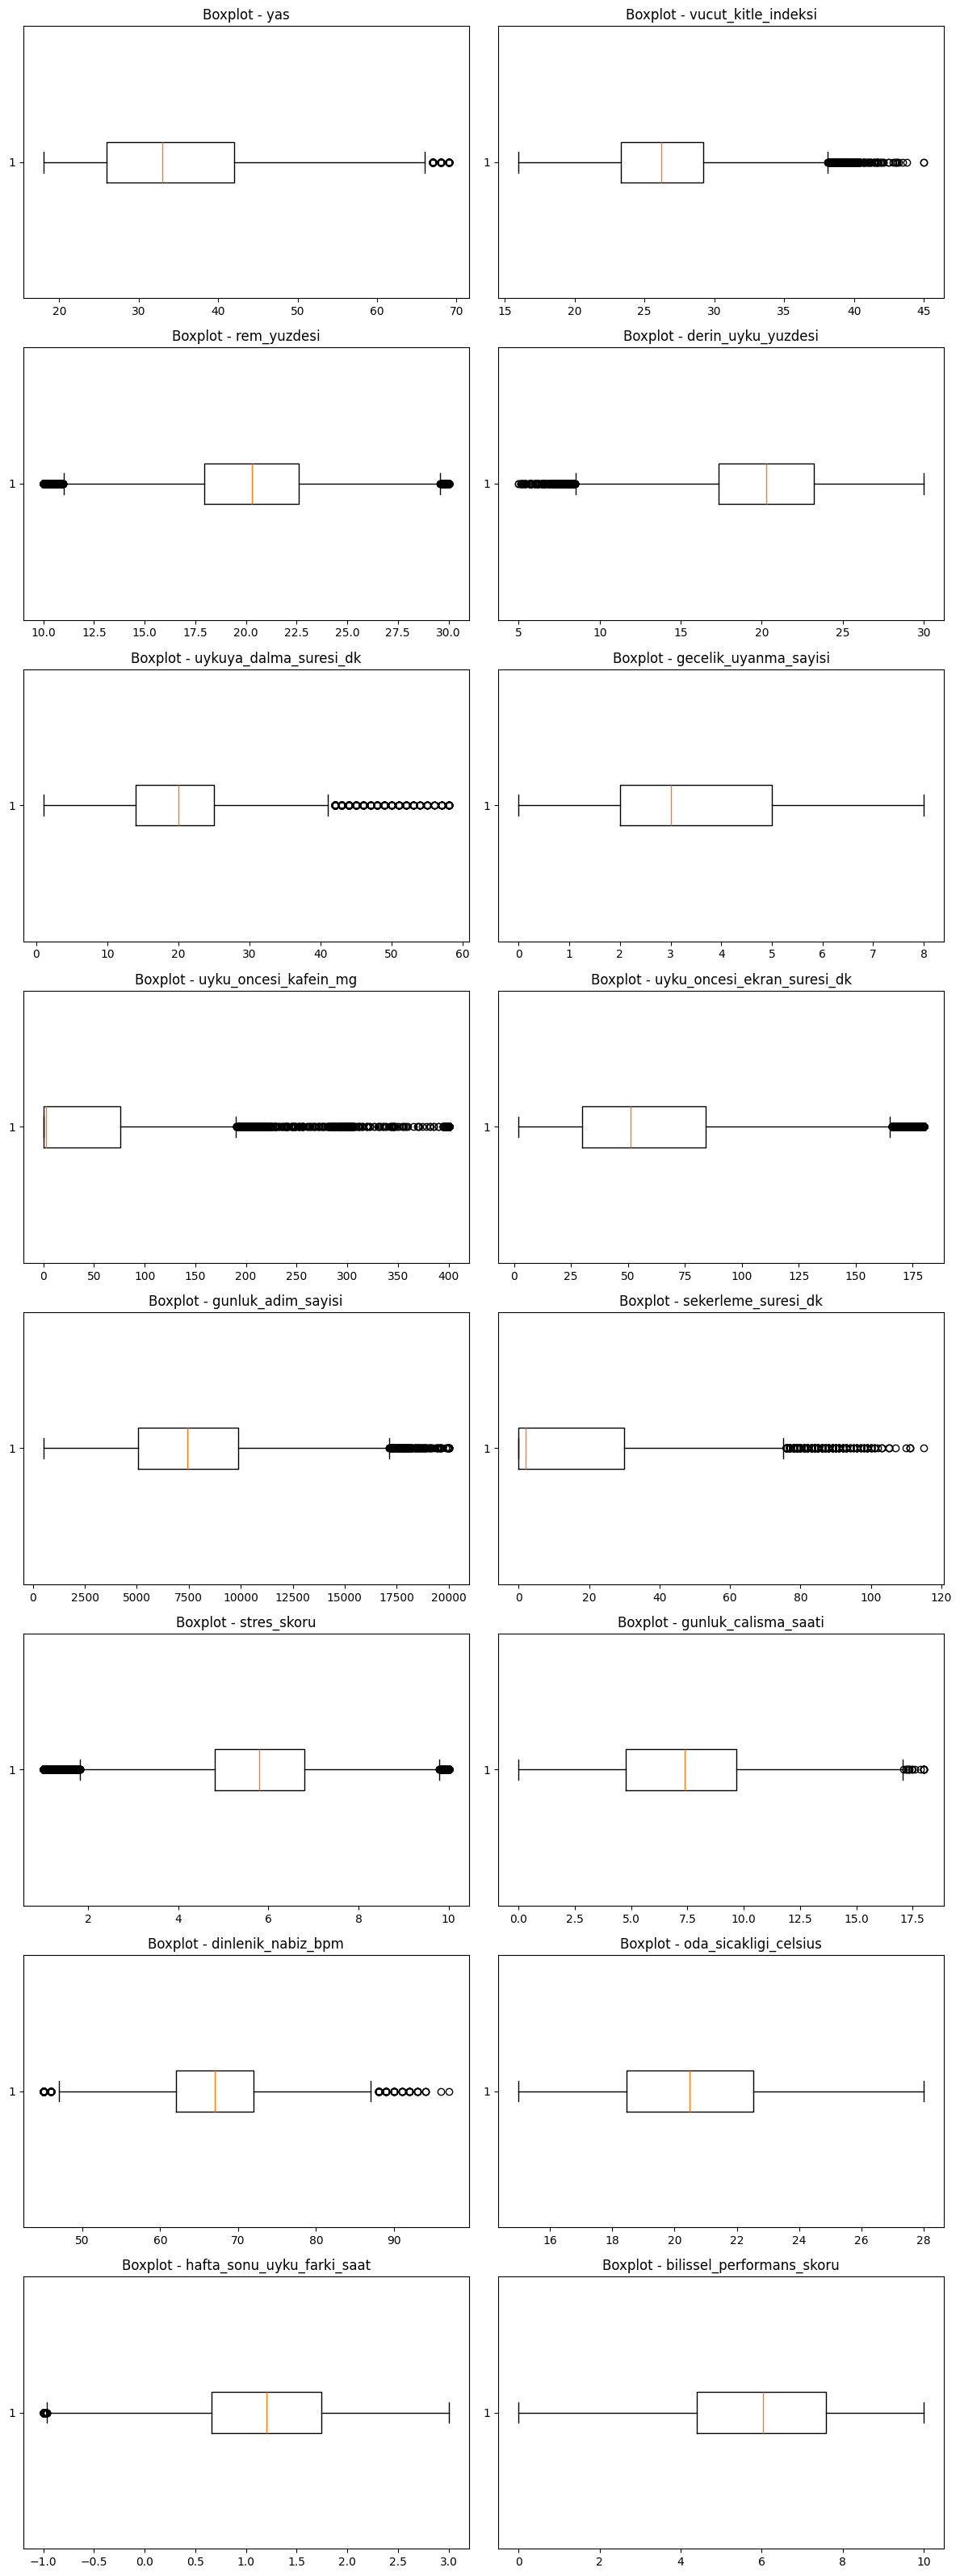

In [21]:
#Identify numeric columns to a list.
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

def handle_outliers(df, numeric_cols):
    #Visualize the distribution of numeric columns using boxplots.
    n_cols = 2  
    n_rows = math.ceil(len(numeric_cols) / n_cols)

    plt.figure(figsize=(12, 4 * n_rows))

    for i, col in enumerate(numeric_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        plt.boxplot(df[col], vert=False)
        plt.title(f"Boxplot - {col}")

    plt.tight_layout()
    plt.show()

handle_outliers(df, numeric_cols)

##### 🔍 4.1 Outlier Analysis & Observations

After visualizing the numerical features using boxplots, the following observations were made regarding the data distribution and potential outliers:

##### - Features Requiring Attention (Significant Outliers)
* **`vucut_kitle_indeksi` (BMI):** There is a dense cluster of outliers on the right side (values between 40-45). While morbid obesity is biologically possible, this concentration might skew the model's ability to generalize for the average population.
* **`uyku_oncesi_kafein_mg`:** This is the most striking distribution. While the majority of the data lies between 0-100 mg, there is a massive "cloud" of outliers ranging from 200 to 400 mg. Consuming 400 mg of caffeine (approx. 4-5 cups of coffee) right before sleep is an extreme case.
* **`gunluk_adim_sayisi`:** Values between 17,500 and 20,000 steps are flagged as outliers. Although 20,000 steps (~15km) is achievable, it remains statistically "unusual" compared to the rest of the dataset.
* **`sekerleme_suresi_dk`:** There is a significant tail extending from 80 to 120 minutes, indicating unusually long daytime naps (up to 2 hours).

##### - Clean Distributions
* **`yas`**, **`dinlenik_nabiz_bpm`**, and **`oda_sicakligi_celsius`**: These features show very healthy distributions with minimal outliers that fall within logical, real-world boundaries.
* **`bilissel_performans_skoru` (Target):** The target variable shows almost no outliers and follows a balanced, near-normal distribution. This is excellent news for model training and stability.

---

> **Decision:** To prevent the model from overfitting to extreme lifestyles while preserving data volume, a **Capping (Winsorization)** strategy will be applied at the 1st and 99th percentiles for the identified features.

In [22]:
def correct_outliers(df, col, lower_percentile=0.01, upper_percentile=0.99):
    lower_limit = df[col].quantile(lower_percentile)
    upper_limit = df[col].quantile(upper_percentile)
    
    # Sınırların dışındakileri sınırlara eşitle
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)
    return df

# Kritik sütunlara uygula
outlier_cols = ['vucut_kitle_indeksi', 'uyku_oncesi_kafein_mg', 'gunluk_adim_sayisi', 'sekerleme_suresi_dk']
for col in outlier_cols:
    df = correct_outliers(df, col)

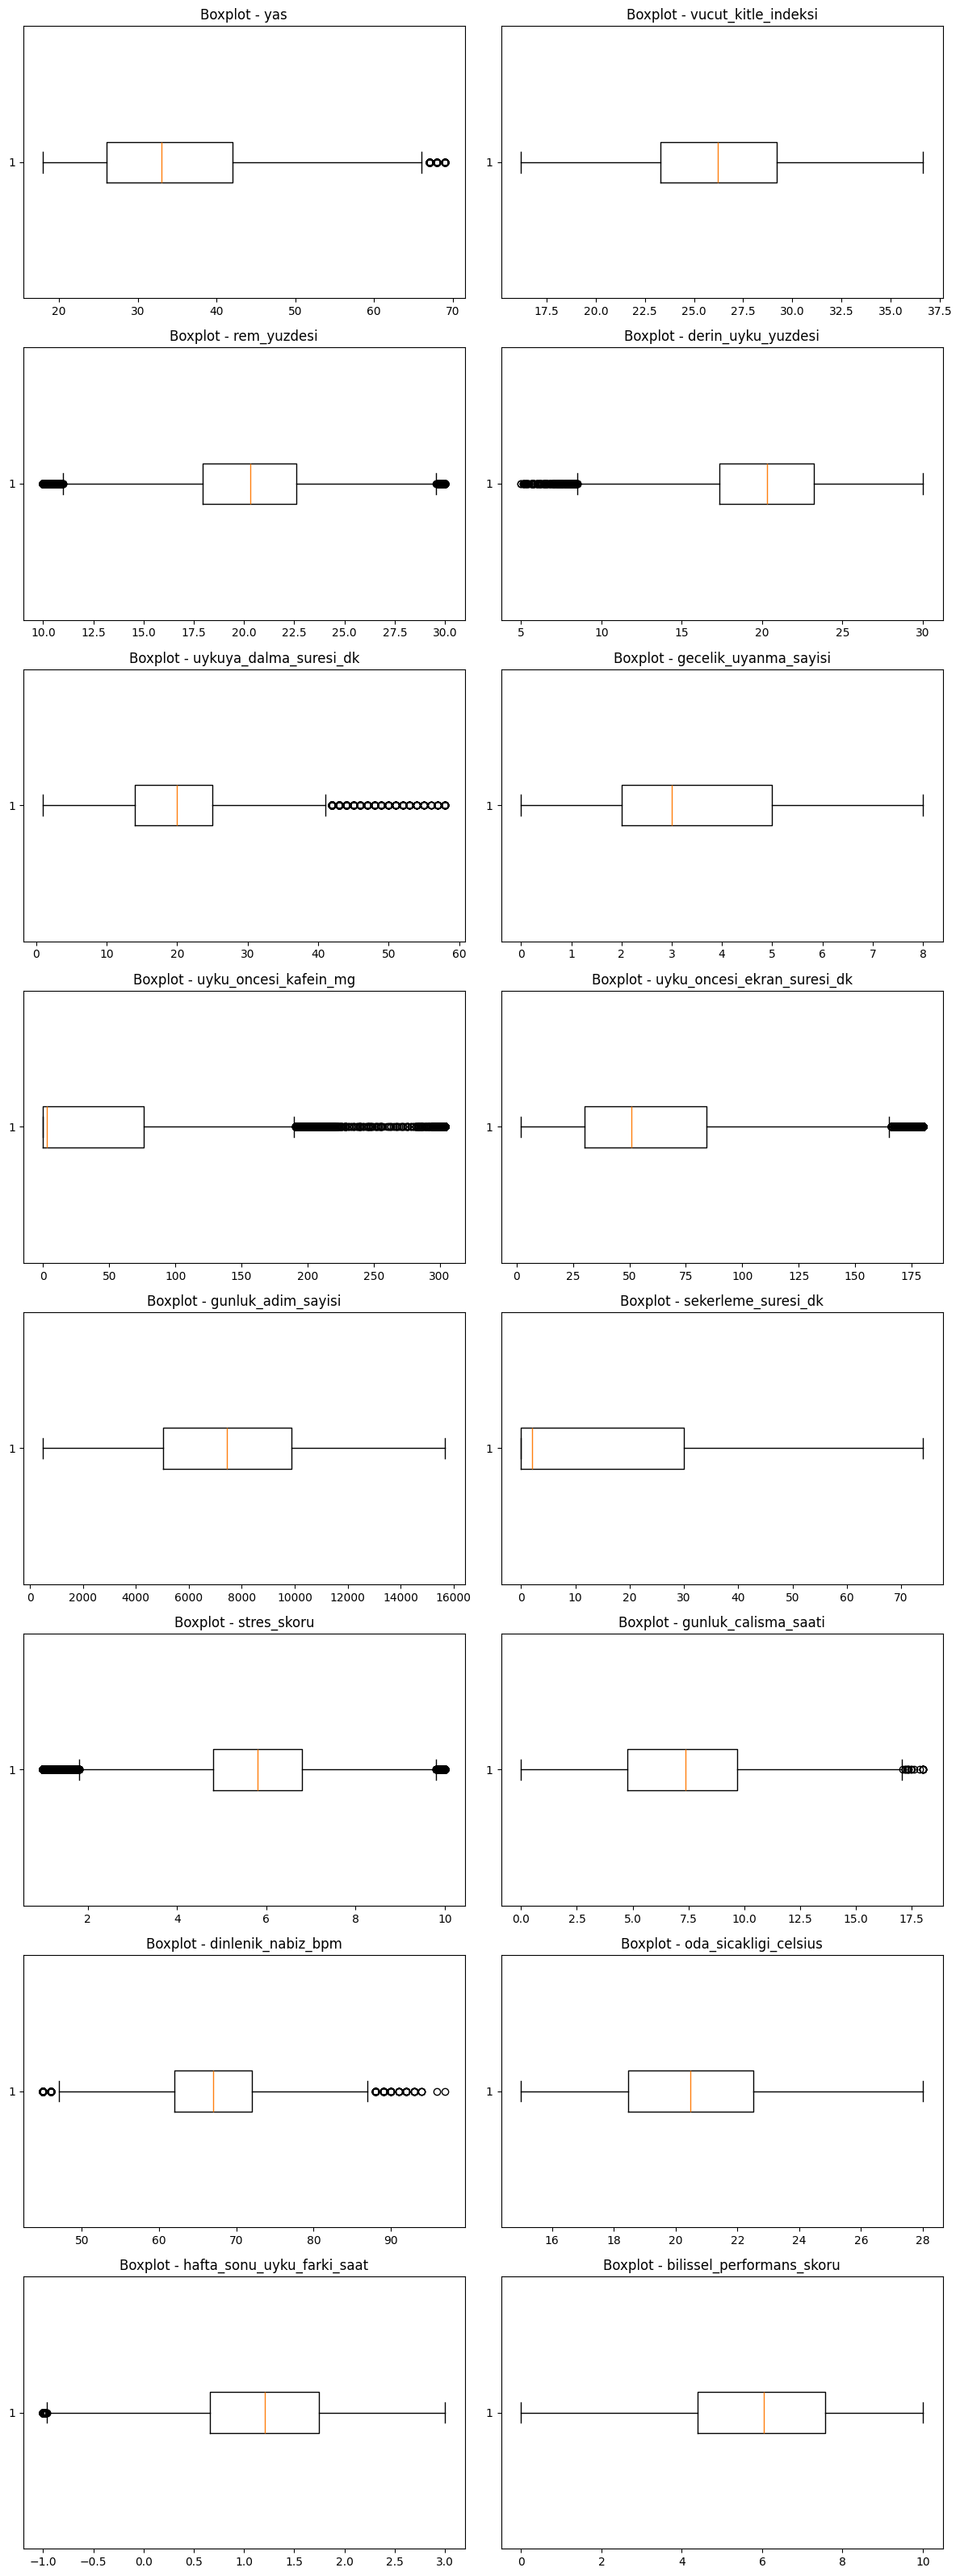

In [23]:
# Post-correction boxplots to visualize the effect of outlier handling.
handle_outliers(df, numeric_cols)

In [24]:
def iqr_filter(df, columns):
    initial_shape = df.shape[0]
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Filtreleme (Capping yerine bu sefer siliyoruz veya sınırlıyoruz)
        # Genelde IQR sonrası silme (dropping) tercih edilir:
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    final_shape = df.shape[0]
    print(f"Başlangıç satır sayısı: {initial_shape}")
    print(f"Filtreleme sonrası satır sayısı: {final_shape}")
    print(f"Kaybedilen veri: {initial_shape - final_shape} satır (%{(initial_shape - final_shape)/initial_shape*100:.2f})")
    
    return df

# Tüm sayısal sütunlara (target hariç) uygulayalım
df_clean = iqr_filter(df.copy(), numeric_cols)

Başlangıç satır sayısı: 56000
Filtreleme sonrası satır sayısı: 47049
Kaybedilen veri: 8951 satır (%15.98)


> - The IQR method causes us to lose a significant portion of the data. Since we want to increase the RMSE value, this method may lead to the loss of useful information. Therefore, we will leave it as is, with only the Capping application.

#### 5. Feature Encoding

##### 🛠️ Feature Encoding Strategy

To make the categorical variables interpretable by machine learning algorithms, we are implementing a dual encoding strategy based on the nature of each feature:

##### 5.1 Binary Encoding (0 and 1 Transformation)
Since these columns contain exactly two unique options, we convert them directly into 0 and 1. This provides the most concise information to the model without increasing dimensionality unnecessarily.

* **`cinsiyet`:** Erkek (0) / Kadin (1)
* **`mevsim`:** Sonbahar-Kis (0) / Ilkbahar-Yaz (1)
* **`gun_tipi`:** Hafta ici (0) / Hafta sonu (1)

##### 5.2 One-Hot Encoding (Dummy Variables)
These columns contain more than two categories with no inherent mathematical hierarchy (e.g., a "Engineer" is not numerically "greater" than a "Doctor"). We create separate binary columns for each category to represent these nominal relationships correctly.

* **`meslek`** (12 categories)
* **`ulke`** (12 categories)
* **`kronotip`** (3 categories)
* **`ruh_sagligi_durumu`** (4 categories)

---
> **Note:** We use `drop_first=True` during One-Hot Encoding to avoid the **Dummy Variable Trap**, ensuring that the model remains statistically stable and free from multi-collinearity.

In [25]:
# 1. Binary Encoding 
df['cinsiyet'] = df['cinsiyet'].map({'Erkek': 0, 'Kadin': 1})
df['mevsim'] = df['mevsim'].map({'Sonbahar-Kis': 0, 'Ilkbahar-Yaz': 1})
df['gun_tipi'] = df['gun_tipi'].map({'Hafta ici': 0, 'Hafta sonu': 1})

# 2. One-Hot Encoding (pd.get_dummies)
# Using drop_first=True to avoid the "Dummy Variable Trap".
cols_to_ohe = ['meslek', 'ulke', 'kronotip', 'ruh_sagligi_durumu']
df = pd.get_dummies(df, columns=cols_to_ohe, drop_first=True)

# 3. Check the final structure of the cleaned dataframe.
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56000 entries, 0 to 55999
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   yas                                        56000 non-null  int64  
 1   cinsiyet                                   56000 non-null  int64  
 2   vucut_kitle_indeksi                        56000 non-null  float64
 3   rem_yuzdesi                                56000 non-null  float64
 4   derin_uyku_yuzdesi                         56000 non-null  float64
 5   uykuya_dalma_suresi_dk                     56000 non-null  int64  
 6   gecelik_uyanma_sayisi                      56000 non-null  int64  
 7   uyku_oncesi_kafein_mg                      56000 non-null  float64
 8   uyku_oncesi_ekran_suresi_dk                56000 non-null  int64  
 9   gunluk_adim_sayisi                         56000 non-null  float64
 10  sekerleme_suresi_dk   

### 6. Scaling

#### 6.1 Plot Histograms

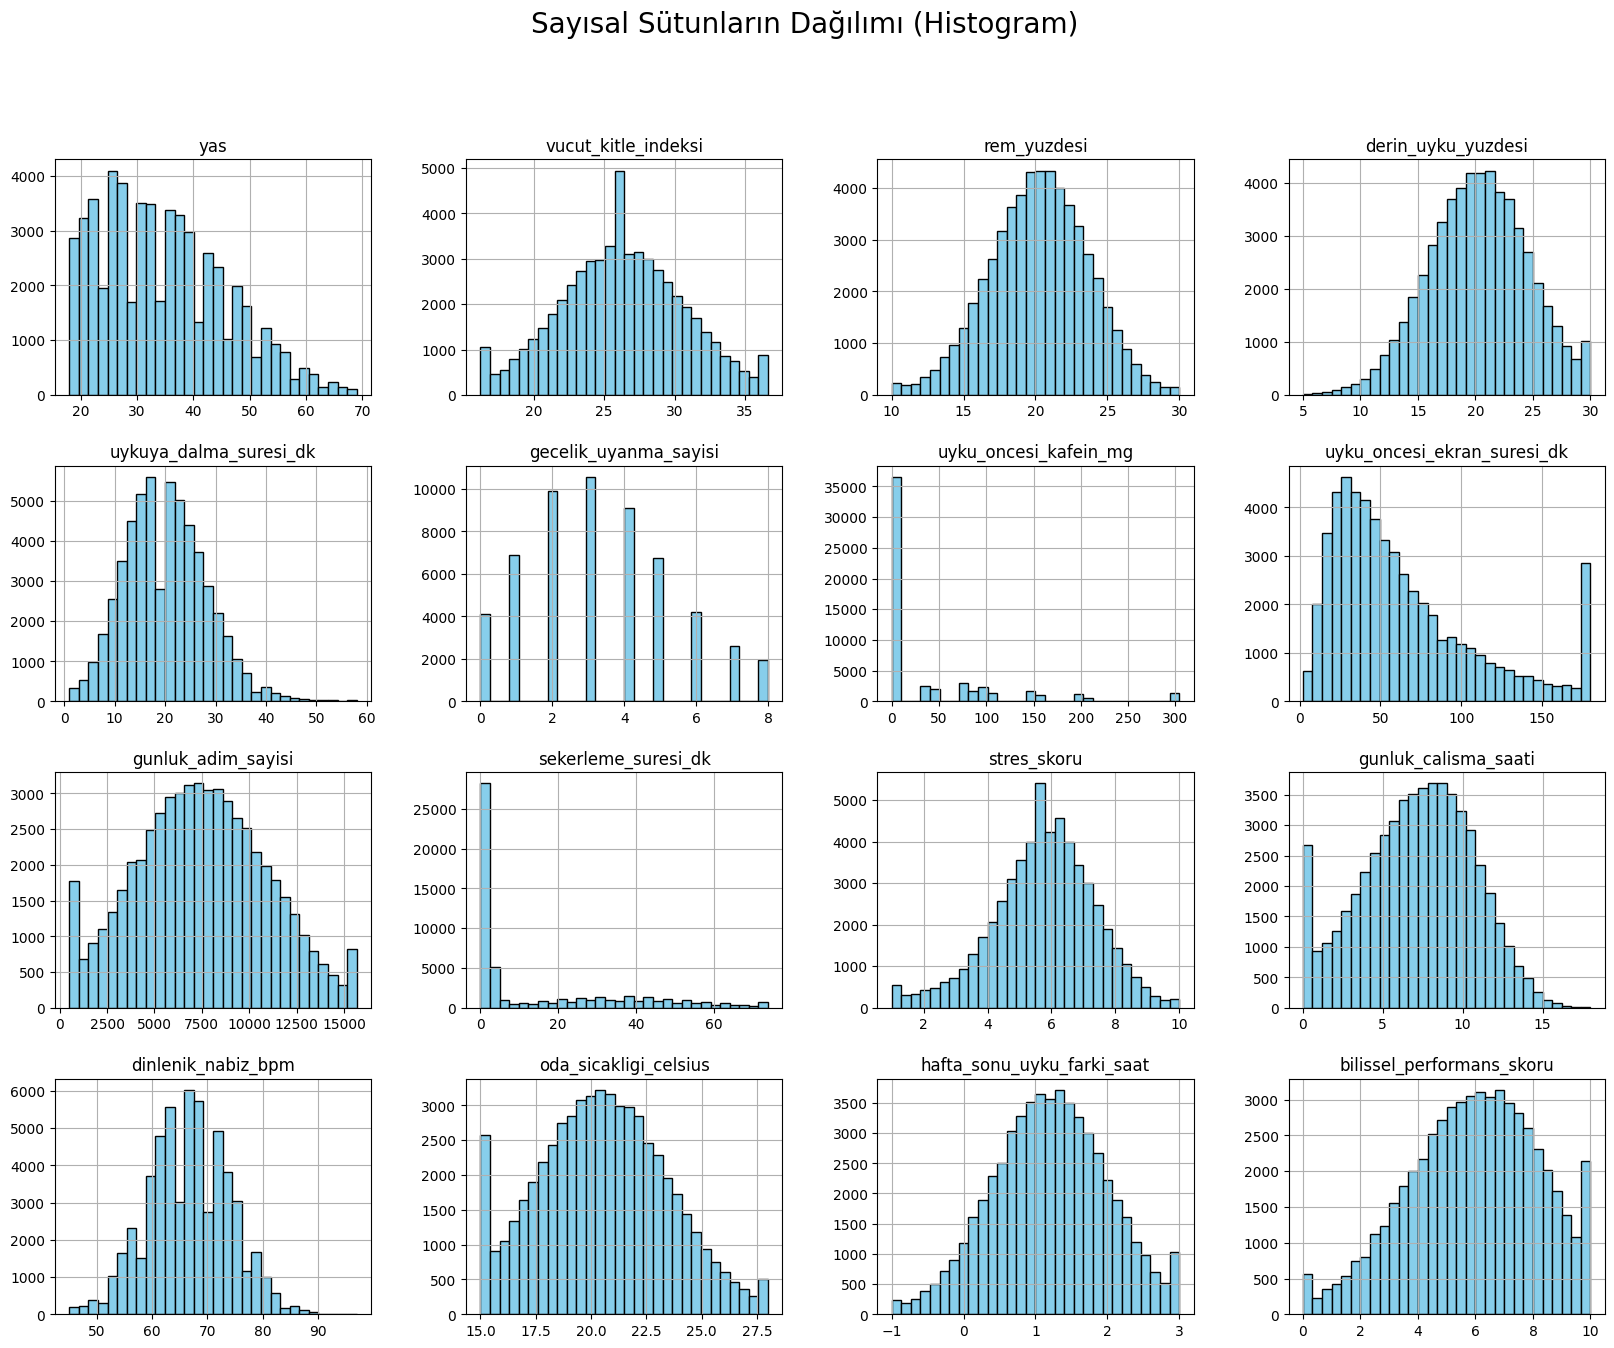

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

df[numeric_cols].hist(bins=30, figsize=(20, 15), color='skyblue', edgecolor='black')
plt.suptitle("Sayısal Sütunların Dağılımı (Histogram)", fontsize=20)
plt.show()

#### 📊 Distribution Analysis Summary

Visual inspection of the histograms reveals the following:
* **Normal Distributions:** Features like `rem_yuzdesi`, `derin_uyku_yuzdesi`, and `stres_skoru` follow a near-perfect Gaussian distribution, making them ideal for **StandardScaler**.
* **Skewed Data:** Caffeine intake and nap durations are heavily right-skewed, reflecting realistic behavioral patterns where extreme values are rare.
* **Target Variable:** `bilissel_performans_skoru` is well-balanced and spans the full 0-10 range, providing a robust signal for the regression model.

**Decision:** We will proceed with **StandardScaler** for feature scaling to ensure all numerical inputs are on a comparable scale without distorting their underlying distributions.

#### 6.2 Apply Scaling

In [27]:


# 1. Independent variables (X) and Target variable (y) separation
X = df.drop(['bilissel_performans_skoru'], axis=1) 
y = df['bilissel_performans_skoru']

# 2. Divide the dataset into training and testing sets (80% train, 20% test)
# To ensure reproducibility, we set random_state=42 so that the same split is obtained every time you run it.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. StandardScaler 
scaler = StandardScaler()

# 4. Only Fit and Transform on Training Data (learns the mean and std from training data and applies it)
# Scaler, learns the mean and std from the training data (fit) and applies it (transform)
X_train_scaled = scaler.fit_transform(X_train)

# 5. Apply only Transform on Test Data (uses the values learned from training)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")
print("\nScaling completed. Data is now ready for modeling!")

Training set size: (44800, 46)
Test set size: (11200, 46)

Scaling completed. Data is now ready for modeling!
